In [ ]:
##regresion lineal coste de incidente de seguridad
#en este ejercicio se explicaran los funadmentos basicos de la regresion lineal aplicada  a un caso sencillo relacionado con la ciberseguridad

#enunciado del ejericicio
#Este ejercicio consiste en predecir el costo de un incidente de seguridad en base al numero que se haya visto afectado. el conjunto de datos es generado de manera aleatoria.


In [ ]:
### realizar importaciones


In [4]:
### generacion del conjunto de datos


In [7]:
import numpy as np
x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.rand(100,1)
print("Longitud de datos:", len(x))

Longitud de datos: 100


In [ ]:
### Visualizacion del conjunto de datos


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

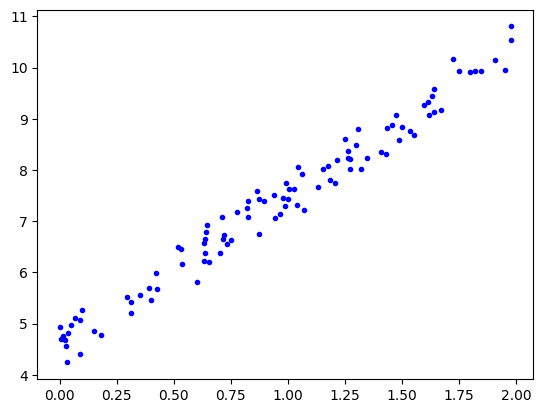

In [10]:
plt.plot(x,y,"b.")
plt.show()

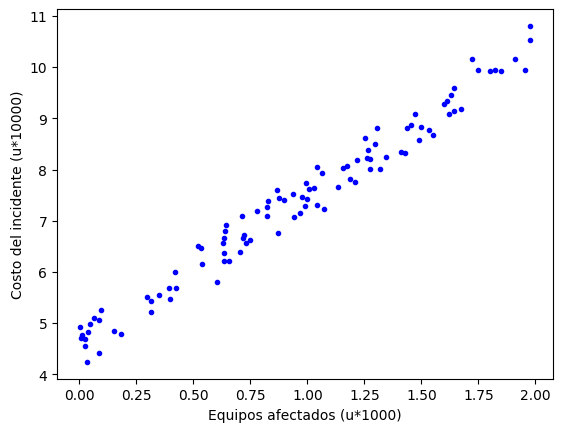

In [11]:
plt.plot(x,y,"b.")
plt.xlabel("Equipos afectados (u*1000)")
plt.ylabel("Costo del incidente (u*10000)")
plt.show()

### modificacion del conjunto de datos


In [12]:
import pandas as pd

convertimos los datos a su valor real en lugar de factores de conversion

In [15]:
data = {'n_equipos_afectados' : x.flatten(), 'costo' : y.flatten() }
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,costo
0,1.262357,8.233548
1,0.822691,7.259437
2,1.436659,8.816658
3,0.000595,4.925497
4,1.455564,8.872559
5,1.820856,9.934336
6,0.005679,4.706916
7,0.350622,5.552835
8,0.631985,6.215737
9,1.909144,10.158569


In [28]:
#escalado del numero de equipos afectados a un valor mas real
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')

#escalado del costo a un valor mas real
df['costo'] = df['costo'] * 10000
df['costo'] = df['costo'].astype('int')

df.head(10)

,n_equipos_afectados,costo
0,1262357000,823350000
1,822690000,725940000
2,1436658000,881660000
3,594000,492540000
4,1455563000,887250000
5,1820855000,993430000
6,5678000,470690000
7,350622000,555280000
8,631984000,621570000
9,1909143000,1015850000


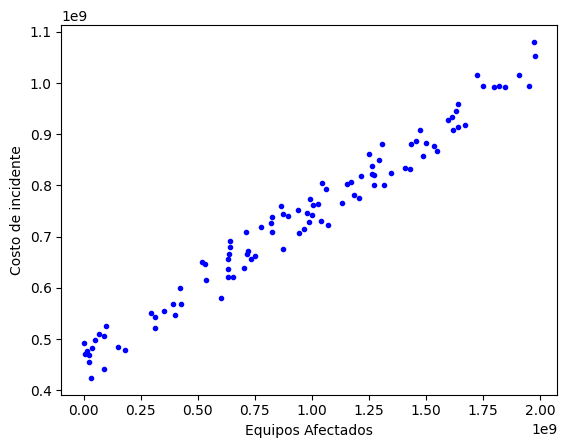

In [29]:
#representacion grafica del conjunto de datos
plt.plot(df['n_equipos_afectados'],df['costo'], "b.")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo de incidente")
plt.show()

### construccion  del modelo

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
#carga del modelo y ajuste de la funcion de hipotesis
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1,1), df['costo'].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
#muestra el valor que se asigno al parametro theta(lugar donde corta la columna y)
lin_reg.intercept_

np.float64(462020687.99585277)

In [33]:
# Mueztra el valor que se le asigno  al parametro theta1 (pendiente que tendra el modelo de regresion lineal)
lin_reg.coef_

array([0.28847592])

### PRediccion para el valor minimo y maximo del conjunto de datos de entrenamiento

In [34]:
x_min_max = np.array([[df['n_equipos_afectados'].min()],[df['n_equipos_afectados'].max()]])
y_train_tred = lin_reg.predict(x_min_max)

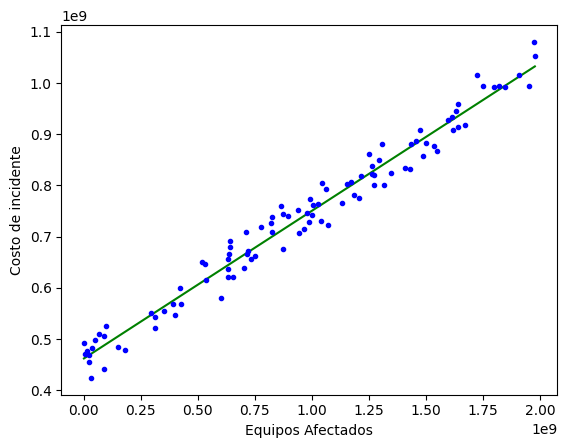

In [35]:
#representacion grafica de la funcion de hipotesis generada
plt.plot(x_min_max, y_train_tred, "g-")
plt.plot(df['n_equipos_afectados'],df['costo'], "b.")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo de incidente")
plt.show()

In [43]:
x_new = np.array([[760000000]]) #760 equipos afectados
# prediccion del costo que tendria este incidente
costo = lin_reg.predict(x_new)
print("El costo del incidente seria:", int((costo[0])), "$")

El costo del incidente seria: 681262385 $


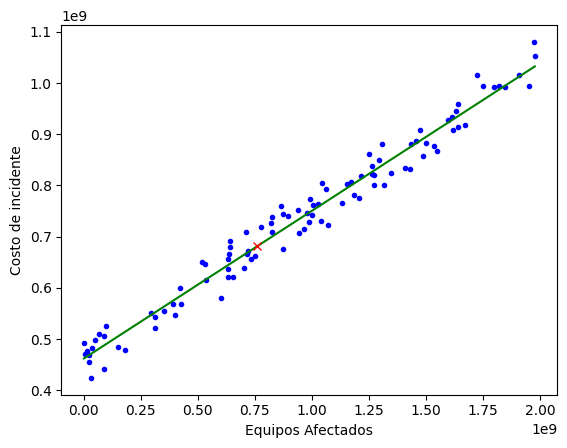

In [44]:
plt.plot(df['n_equipos_afectados'], df['costo'], "b.")
plt.plot(x_min_max, y_train_tred, "g-")
plt.plot(x_new, costo, "rx")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo de incidente")
plt.show()